#### Libraries

In [1]:
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

#### Data

In [2]:
fc = 210
fy = 4200
tl = 0.4
tc = 0.4
Pd = 35
Pl = 30
qa = 20
qu_suelo = qa*3
fiV = 0.70
lamda = 1.0
alfas = 40.0 
rec = 0.04
df = 2.0
dH = 2.4
dS = 1.9

d = sp.Symbol('d')

#### Pre - Sizing

In [3]:
Pt = Pd + Pl

A = Pt / qa
B = np.sqrt(A)
B = np.ceil(B / 0.05) * 0.05
A = B**2
qo = Pt / A

Psu = 1.4*Pd + 1.6*Pl
qsu = Psu / A

A_df = pd.DataFrame({'Area [m2]':[A]})
B_df = pd.DataFrame({'B [m]':[B]})
Pt_df = pd.DataFrame({'Pt [T]':[Pt]})
Psu_df = pd.DataFrame({'Psu [T]':[Psu]})
qo_df = pd.DataFrame({'qo [T/m2]':[qo]})
qsu_df = pd.DataFrame({'qsu [T/m2]':[qsu]})

if qo <= qa:
    mensaje = '😎'
else:
    mensaje = '💀'

mensaje_df = pd.DataFrame({'Qo <= Qa':[mensaje]})

Resul_parcial = pd.concat([A_df, B_df, Pt_df, Psu_df, qo_df, qsu_df, mensaje_df], axis = 1, ignore_index= False)
Resul_parcial

,Area [m2],B [m],Pt [T],Psu [T],qo [T/m2],qsu [T/m2],Qo <= Qa
0,3.4225,1.85,65,97.0,18.991965,28.341855,😎


##### Vu

In [4]:
#----- Vu
Vu = Psu - qsu * (d + tc)*(d+tl)
Vu

-(d + 0.4)*(28.3418553688824*d + 11.336742147553) + 97.0

##### ΦVc

![alt text](image.png)
![alt text](image-2.png)
![alt text](image-3.png)
![alt text](image-4.png)

In [5]:
d_sym = sp.Symbol('d')
d_sym_cm = d_sym * 100
bw_sym = 2*(d_sym + tc) + 2*(d_sym + tl)
bw_sym_cm = bw_sym * 100
beta = tl / tc
lamdas = sp.sqrt(2 / (1 + 0.04 * d_sym))

#----a)
fiVc_a = fiV * 1.1 * lamdas * lamda * sp.sqrt(fc) * bw_sym_cm * d_sym_cm / 1000
#----b)
fiVc_b = fiV * 0.53 * (1 + 2/beta) * lamdas * lamda * sp.sqrt(fc) * bw_sym_cm * d_sym_cm / 1000
#----c)
fiVc_c = fiV * 0.27 * (2 + (alfas * d_sym_cm) / bw_sym_cm) * lamda * sp.sqrt(fc) * bw_sym_cm * d_sym_cm / 1000

In [6]:
fiVc_a

0.154*sqrt(105)*d*(400*d + 160.0)*sqrt(1/(0.04*d + 1))

In [7]:
fiVc_b

0.2226*sqrt(105)*d*(400*d + 160.0)*sqrt(1/(0.04*d + 1))

In [8]:
fiVc_c

sqrt(210)*d*(400*d + 160.0)*(756.0*d/(400*d + 160.0) + 0.378)/10

##### Solver

In [9]:
sol_a = sp.solve(sp.Eq(fiVc_a, Vu), d_sym)
sol_a = float(np.max([float(s.evalf()) for s in sol_a if s.is_real and s > 0]))
sol_b = sp.solve(sp.Eq(fiVc_b, Vu), d_sym)
sol_b = float(np.max([float(s.evalf()) for s in sol_b if s.is_real and s > 0]))
sol_c = sp.solve(sp.Eq(fiVc_c, Vu), d_sym)
sol_c = float(np.max([float(s.evalf()) for s in sol_c if s.is_real and s > 0]))

d = float(np.max([sol_a, sol_b, sol_c]))
Vu = float(Psu - qsu * (d + tc)*(d + tl))

print(f'sol_a = {sol_a:.4f} m')
print(f'sol_b = {sol_b:.4f} m')
print(f'sol_c = {sol_c:.4f} m')
print(f'd     = {d:.4f} m')
print(f'Vu    = {Vu:.4f} T')

sol_a = 0.2207 m
sol_b = 0.1695 m
sol_c = 0.2245 m
d     = 0.2245 m
Vu    = 85.9461 T


##### Shear Results

In [10]:
lamdas = sp.sqrt(2 / (1 + 0.04 * d))

if lamdas <= 1:
    lamdas = lamdas
else:
    lamdas = 1.0

dd = d

DCR = 2

while DCR >= 1:
    d = dd
    H = np.ceil((d + rec)/0.05)*0.05
    d = H - rec
    
    # ─── CONVERSIÓN A CM PARA FÓRMULAS ACI ───────────────────────────────
    d_cm_shear  = d * 100           # cm
    bw_cm_shear = 2*(d_cm_shear + tc*100) + 2*(d_cm_shear + tl*100)  # perímetro en cm

    lamdas_df = pd.DataFrame({' λs': [lamdas]})
    lamda_df  = pd.DataFrame({' λ':  [lamda]})

    # ─── ΦVc en kg → dividir entre 1000 para obtener T ──────────────────
    #----a)
    EfiVc_a = fiV * 1.1 * lamdas * lamda * sp.sqrt(fc) * bw_cm_shear * d_cm_shear / 1000
    #----b)
    EfiVc_b = fiV * 0.53 * (1 + 2/beta) * lamdas * lamda * sp.sqrt(fc) * bw_cm_shear * d_cm_shear / 1000
    #----c)
    EfiVc_c = fiV * 0.27 * (2 + (alfas * d_cm_shear) / bw_cm_shear) * lamda * sp.sqrt(fc) * bw_cm_shear * d_cm_shear / 1000
    #----fiVc max
    EfiVc_max = fiV * 1.33 * lamda * np.sqrt(fc) * bw_cm_shear * d_cm_shear / 1000

    if np.max([EfiVc_a, EfiVc_b, EfiVc_c]) <= EfiVc_max:
        EfiVc = np.max([EfiVc_a, EfiVc_b, EfiVc_c])
    else:
        EfiVc = EfiVc_max

    H_df         = pd.DataFrame({'H [m]':      [H]})
    d_df         = pd.DataFrame({'d [m]':      [d]})
    EfiVc_a_df   = pd.DataFrame({'ΦVc_a [T]':  [float(EfiVc_a.evalf())]})
    EfiVc_b_df   = pd.DataFrame({'ΦVc_b [T]':  [float(EfiVc_b.evalf())]})
    EfiVc_c_df   = pd.DataFrame({'ΦVc_c [T]':  [float(EfiVc_c.evalf())]})
    EfiVc_max_df = pd.DataFrame({'ΦVc_max [T]':[float(EfiVc_max)]})
    EfiVc_df     = pd.DataFrame({'ΦVc [T]':    [float(EfiVc)]})
    EVu_df       = pd.DataFrame({'Vu [T]':     [float(Vu)]})

    DCR = Vu / EfiVc
    if DCR <= 1:
        mensaje2 = "😎"
    else:
        mensaje2 = "💀"

    dd = dd + 0.05

    DCR_df      = pd.DataFrame({'DCR':      [float(DCR)]})
    mensaje2_df = pd.DataFrame({'Revision': [mensaje2]})

    Resul_Shear = pd.concat([H_df, d_df, lamda_df, lamdas_df, EVu_df, EfiVc_a_df, EfiVc_b_df, EfiVc_c_df, EfiVc_max_df, EfiVc_df, DCR_df, mensaje2_df], axis=1, ignore_index=False)

Resul_Shear

,H [m],d [m],λ,λs,Vu [T],ΦVc_a [T],ΦVc_b [T],ΦVc_c [T],ΦVc_max [T],ΦVc [T],DCR,Revision
0,0.3,0.26,1.0,1.0,85.946096,76.590984,110.708786,111.658261,92.605462,92.605462,0.928089,😎


##### Calculation of Self Weight and Total Load

In [11]:
#------- Self Weight Column
volCol = tc*tl*(df - H)
ppCol = volCol * dH
#------- Self Weight Foundation
volZa = B * B * H
ppZa = volZa * dH
#------- Self Weight Terrain
volExc = B * B * df
volRell = volExc - (volCol + volZa)
ppRell = volRell * dS

## total Weigth (PT = P + Pp(col+rell+foundation))
PT = Pt + ppCol + ppZa + ppRell

ppCol_df = pd.DataFrame({'Pp Column [T]':[ppCol]})
ppZa_df = pd.DataFrame({'Pp Foundation [T]':[ppZa]})
pprRell_df = pd.DataFrame({'Pp Terrain [T]':[ppRell]})

PT_df = pd.DataFrame({'Total Weight [T]': [PT]})

if PT <= Psu:
    mensaje3 = "😎"
else:
    mensaje3 = "💀, Recalculate d"
mensaje3_df = pd.DataFrame({'Revision': [mensaje3]})

RT = pd.concat([ppCol_df, ppZa_df, pprRell_df, Pt_df, PT_df, Psu_df, mensaje3_df], axis=1, ignore_index= False)
RT


,Pp Column [T],Pp Foundation [T],Pp Terrain [T],Pt [T],Total Weight [T],Psu [T],Revision
0,0.6528,2.4642,10.537875,65,78.654875,97.0,😎


##### Summary of Sizing

In [12]:
fc_df = pd.DataFrame({'fc [kg/cm2]':[fc]})
DCRq = 2

BB = B
while DCRq >= 1:
    A = BB * BB
    
    #------- Self Weight Foundation
    volZa = BB * BB * H
    ppZa = volZa * dH
    #------- Self Weight Terrain
    volExc = BB * BB * df
    volRell = volExc - (volCol + volZa)
    ppRell = volRell * dS

    PT = Pt + ppCol + ppZa + ppRell

    qo = PT / A
    DCRq = qo / qa

    if DCRq >= 1:
        BB = BB + 0.10

B = BB   # ← actualizar B con el valor correcto

BB_df = pd.DataFrame({'B [m]':[BB]})

if qo <= qa:
    DCRq = qo/qa
    mensaje = '😎'
else:
    DCRq = qo/qa
    mensaje = '💀'

DCRq_df    = pd.DataFrame({'DCR q':[DCRq]})
qo_df      = pd.DataFrame({'qo [T/m2]':[qo]})
qa_df      = pd.DataFrame({'qa [T/m2]':[qa]})
ppCol_df   = pd.DataFrame({'Pp Column [T]':[ppCol]})
ppZa_df    = pd.DataFrame({'Pp Foundation [T]':[ppZa]})
pprRell_df = pd.DataFrame({'Pp Terrain [T]':[ppRell]})
PT_df      = pd.DataFrame({'Total Weight [T]': [PT]})

if PT <= Psu:
    mensaje3 = "😎"
else:
    mensaje3 = "💀, Recalculate d"
mensaje3_df = pd.DataFrame({'Revision Pt <= Psu': [mensaje3]})

mensaje_df = pd.DataFrame({'Qo <= Qa':[mensaje]})

SummarySizing = pd.concat([fc_df, BB_df, H_df, d_df, PT_df, qo_df, qa_df, DCRq_df, mensaje_df, mensaje3_df], axis=1, ignore_index=False)
SummarySizing

,fc [kg/cm2],B [m],H [m],d [m],Total Weight [T],qo [T/m2],qa [T/m2],DCR q,Qo <= Qa,Revision Pt <= Psu
0,210,2.05,0.3,0.26,81.735875,19.449346,20,0.972467,😎,😎


#### Flexural Design

In [13]:
B = BB
bw = 1.0
Pu = 1.4*(ppCol + ppZa + ppRell + Pd) + 1.6*(Pl)
qu = Pu / A
wu = qu * bw
# print(Pu, qu, qu_suelo, wu)
Mux = np.zeros(11)
lx = np.zeros(11)
x = 0
for i in np.arange(0, 10+1, 1):
    Mux[i] = (wu*(x**2)/2)
    lx[i] = x
    x = x + 0.10*(B/2)

Mux_df = pd.DataFrame(Mux, columns=['Mux [T-m]'])
lx_df = pd.DataFrame(lx, columns= ['Distancia [m]'])
Flexion = pd.concat([lx_df, Mux_df], axis =1, ignore_index= False)
Flexion

,Distancia [m],Mux [T-m]
0,0.0000,0.000000
1,0.1025,0.150538
2,0.2050,0.602151
3,0.3075,1.354840
4,0.4100,2.408605
5,0.5125,3.763445
6,0.6150,5.419360
7,0.7175,7.376351
8,0.8200,9.634418
9,0.9225,12.193560


##### Plotting the Bending Moment Diagram


(0.0, 16.5591559375)

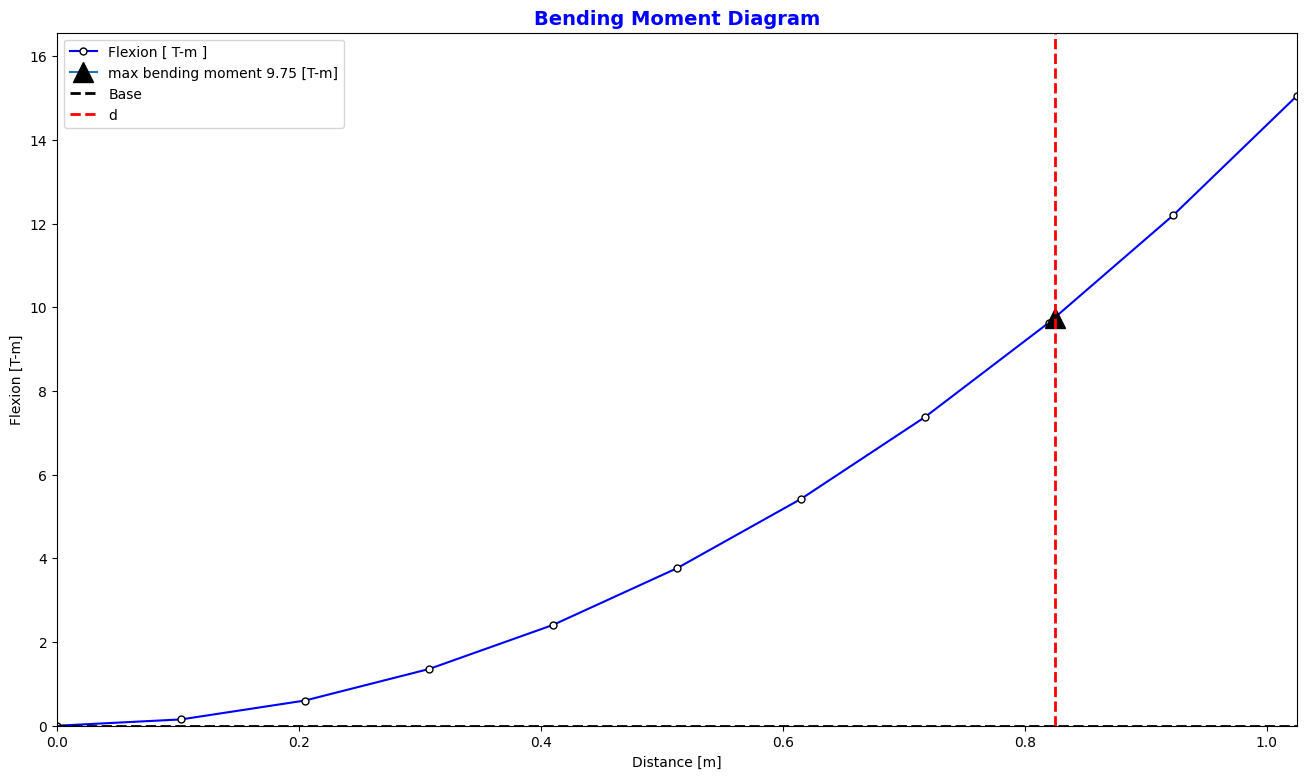

In [14]:
Mumax = wu * (B/2 - tl/2)**2 / 2

fig, ax = plt.subplots(1,1, figsize = (16,9))
ax.plot(lx,Mux, lw = 1.5, ls = '-', color = [0,0,1], marker = 'o',
        markersize = 5, markeredgecolor = [0,0,0], markerfacecolor = [1,1,1], label = 'Flexion [ T-m ]')
ax.plot((B/2 - tl/2),Mumax, marker = '^',
        markersize = 15, markeredgecolor = [0,0,0], markerfacecolor = [0,0,0], label = f'max bending moment {Mumax:.2f} [T-m]')
ax.hlines(0, 0, B/2, lw = 2.0, ls = '--', color = [0,0,0], label = 'Base')
ax.vlines(B/2 - tl/2, 0, Mux.max()*10, lw = 2.0, ls = '--', color = [1,0,0], label = 'd')
ax.legend()
ax.set_xlabel('Distance [m]')
ax.set_ylabel('Flexion [T-m]')
ax.set_title('Bending Moment Diagram', fontsize = 14, fontweight = 'bold', color = [0,0,1])
ax.set_xlim(0, B/2)
ax.set_ylim(0, Mux.max()*1.10)

Conversión de unidades

In [15]:
d_cm  = float(d) * 100          # peralte efectivo en cm
tc_cm = float(tc) * 100         # dimensión columna (lado 1) en cm
tl_cm = float(tl) * 100         # dimensión columna (lado 2) en cm
B_cm  = float(B) * 100          # lado de la zapata en cm
bw_cm = 100.0                   # franja unitaria de 1 m = 100 cm

Mu_kgcm = float(Mumax) * 100000  # T-m → kg-cm
print(f"d_cm  = {d_cm:.2f} cm")
print(f"tc_cm = {tc_cm:.2f} cm")
print(f"tl_cm = {tl_cm:.2f} cm")
print(f"B_cm  = {B_cm:.2f} cm")
print(f"bw_cm = {bw_cm:.2f} cm")
print(f"Mu_kgcm = {Mu_kgcm:.2f} kg-cm")

d_cm  = 26.00 cm
tc_cm = 40.00 cm
tl_cm = 40.00 cm
B_cm  = 205.00 cm
bw_cm = 100.00 cm
Mu_kgcm = 975226.91 kg-cm


Acero mínimo para zapatas 

In [16]:
# ACI 318-19 sección 8.6.1.1
# As_min = 0.0018 · b · h
# donde h = altura total de la zapata (no el peralte efectivo d) 
H_cm = H * 100                        # altura total de la zapata en cm
As_min = 0.0018 * bw_cm * H_cm
print(f"H_cm   = {H_cm:.2f} cm")
print(f"As_min = {As_min:.3f} cm²/m") 
      

H_cm   = 30.00 cm
As_min = 5.400 cm²/m


Acero requerido por flexión

In [17]:
#ACI 318-19 sección 22.2
# Mu = φ·As·fy·(d - a/2)  donde  a = As·fy/(0.85·fc·b)
fiM = 0.90

A_coef = (fy**2) / (2 * 0.85 * fc * bw_cm)
B_coef = -(fy * d_cm)
C_coef = Mu_kgcm / fiM

discriminante = B_coef**2 - 4 * A_coef * C_coef
As_req = (-B_coef - np.sqrt(discriminante)) / (2 * A_coef)  # cm²/m
print(f"fiM          = {fiM:.2f}")
print(f"A_coef       = {A_coef:.6f}")
print(f"B_coef       = {B_coef:.4f}")
print(f"C_coef       = {C_coef:.4f}")
print(f"discriminante= {discriminante:.4f}")
print(f"As_req       = {As_req:.3f} cm²/m")

fiM          = 0.90
A_coef       = 494.117647
B_coef       = -109200.0000
C_coef       = 1083585.4569
discriminante= 9782965214.5082
As_req       = 10.414 cm²/m


Acero de diseño

In [18]:
# Se toma el mayor entre acero mínimo y acero requerido por flexión
As_dis = max(As_req, As_min)
As_min_df = pd.DataFrame({'As_min [cm²/m]': [round(As_min, 3)]})
As_req_df = pd.DataFrame({'As_req [cm²/m]': [round(As_req, 3)]})
As_dis_df = pd.DataFrame({'As_dis [cm²/m]': [round(As_dis, 3)]})

Resul_Acero_min = pd.concat([As_min_df, As_req_df, As_dis_df], axis=1, ignore_index=False)
Resul_Acero_min

,As_min [cm²/m],As_req [cm²/m],As_dis [cm²/m]
0,5.4,10.414,10.414


Acero elegido y número de varillas 

In [19]:
# Separaciones según ACI 318-19 Sección 25.2
# s_min = max(2.54 cm (1"), db)
# s_max = min(5*H, 45 cm (18"))
varillas = {
    3:  {'d_var': 0.953, 'area': 0.713},   # #3  (3/8")
    4:  {'d_var': 1.270, 'area': 1.267},   # #4  (1/2")
    5:  {'d_var': 1.588, 'area': 1.979},   # #5  (5/8")
    6:  {'d_var': 1.905, 'area': 2.850},   # #6  (3/4")
    7:  {'d_var': 2.222, 'area': 3.879},   # #7  (7/8")
    8:  {'d_var': 2.540, 'area': 5.067},   # #8  (1")
}

rec_cm     = rec * 100
ancho_util = B_cm - 2 * rec_cm             #ancho neto entre varillas extremas [cm]
s_max_cm   = min(5 * H_cm, 45.0)          #ACI 318-19 §25.2: menor entre 5H y 45 cm

resultado_varilla = None

for num, datos in varillas.items():
    d_var    = datos['d_var']
    area_var = datos['area']
    s_min_cm = max(2.54, d_var)            # ACI 318-19 §25.2: mayor entre 1" y db

    n_min  = int(np.ceil(As_dis / area_var))
    s_calc = bw_cm / n_min

    if s_min_cm <= s_calc <= s_max_cm:
        resultado_varilla = {
            'numero'     : num,
            'd_var_cm'   : d_var,
            'area_var'   : area_var,
            'n_por_metro': n_min,
            'separacion' : s_calc,
            'As_elegido' : n_min * area_var,
        }
        break

if resultado_varilla is None:
    print("⚠️ Ninguna varilla estándar cumple. Revisar diseño.")
else:
    sep      = resultado_varilla['separacion']
    num_var  = resultado_varilla['numero']
    d_var    = resultado_varilla['d_var_cm']
    area_var = resultado_varilla['area_var']

    n_varillas = int(np.floor(ancho_util / sep)) + 1
    sep_real   = ancho_util / (n_varillas - 1)
    As_total_m = (n_varillas * area_var) / (B_cm / 100)

    s_min_cm = max(2.54, d_var)
    if As_total_m >= As_dis and sep_real >= s_min_cm and sep_real <= s_max_cm:
        rev_acero = "😎"
    else:
        rev_acero = "💀"

    #RESULTADOS
    var_df     = pd.DataFrame({'Varilla #'         : [num_var]})
    smin_df    = pd.DataFrame({'s_min [cm]'        : [round(s_min_cm, 2)]})
    smax_df    = pd.DataFrame({'s_max [cm]'        : [round(s_max_cm, 2)]})
    sep_df     = pd.DataFrame({'Sep real [cm]'     : [round(sep_real, 2)]})
    nvar_df    = pd.DataFrame({'N° varillas/dir'   : [n_varillas]})
    As_eleg_df = pd.DataFrame({'As_eleg [cm²/m]'  : [round(As_total_m, 3)]})
    As_dis_df2 = pd.DataFrame({'As_dis [cm²/m]'   : [round(As_dis, 3)]})
    rev_df     = pd.DataFrame({'As_eleg >= As_dis' : [rev_acero]})

    Resul_Acero = pd.concat(
        [var_df, smin_df, smax_df, sep_df, nvar_df, As_eleg_df, As_dis_df2, rev_df],
        axis=1, ignore_index=False
    )
    display(Resul_Acero)

    print(f"\nRefuerzo: {n_varillas} varillas #{num_var} @ {sep_real:.1f} cm, en ambas direcciones")
    print(f"As elegido = {As_total_m:.3f} cm²/m  |  As dis = {As_dis:.3f} cm²/m")
    print(f"s_min = {s_min_cm:.2f} cm  |  s_max = {s_max_cm:.2f} cm")

,Varilla #,s_min [cm],s_max [cm],Sep real [cm],N° varillas/dir,As_eleg [cm²/m],As_dis [cm²/m],As_eleg >= As_dis
0,3,2.54,45.0,6.79,30,10.434,10.414,😎



Refuerzo: 30 varillas #3 @ 6.8 cm, en ambas direcciones
As elegido = 10.434 cm²/m  |  As dis = 10.414 cm²/m
s_min = 2.54 cm  |  s_max = 45.00 cm


Prueba con varillas de mayor diametro

In [20]:
# s_min = max(2.54 cm (1"), db)
# s_max = min(5*H, 45 cm (18"))
# Búsqueda desde varilla más grande a más pequeña
varillas = {
    8:  {'d_var': 2.540, 'area': 5.067},   # #8  (1")
    7:  {'d_var': 2.222, 'area': 3.879},   # #7  (7/8")
    6:  {'d_var': 1.905, 'area': 2.850},   # #6  (3/4")
    5:  {'d_var': 1.588, 'area': 1.979},   # #5  (5/8")
    4:  {'d_var': 1.270, 'area': 1.267},   # #4  (1/2")
    3:  {'d_var': 0.953, 'area': 0.713},   # #3  (3/8")
}

rec_cm     = rec * 100
ancho_util = B_cm - 2 * rec_cm             # ancho neto entre varillas extremas [cm]
s_max_cm   = min(5 * H_cm, 45.0)          # ACI 318-19 §25.2: menor entre 5H y 45 cm

resultado_varilla = None

for num, datos in varillas.items():
    d_var    = datos['d_var']
    area_var = datos['area']
    s_min_cm = max(2.54, d_var)            # ACI 318-19 §25.2: mayor entre 1" y db

    n_min  = int(np.ceil(As_dis / area_var))
    s_calc = bw_cm / n_min

    if s_min_cm <= s_calc <= s_max_cm:
        resultado_varilla = {
            'numero'     : num,
            'd_var_cm'   : d_var,
            'area_var'   : area_var,
            'n_por_metro': n_min,
            'separacion' : s_calc,
            'As_elegido' : n_min * area_var,
        }
        break

if resultado_varilla is None:
    print("⚠️ Ninguna varilla estándar cumple. Revisar diseño.")
else:
    sep      = resultado_varilla['separacion']
    num_var  = resultado_varilla['numero']
    d_var    = resultado_varilla['d_var_cm']
    area_var = resultado_varilla['area_var']

    n_varillas = int(np.floor(ancho_util / sep)) + 1
    sep_real   = ancho_util / (n_varillas - 1)
    As_total_m = (n_varillas * area_var) / (B_cm / 100)

    s_min_cm = max(2.54, d_var)
    if As_total_m >= As_dis and sep_real >= s_min_cm and sep_real <= s_max_cm:
        rev_acero = "😎"
    else:
        rev_acero = "💀"

    # ─── RESULTADOS ──────────────────────────────────────────────────────
    var_df     = pd.DataFrame({'Varilla #'         : [num_var]})
    smin_df    = pd.DataFrame({'s_min [cm]'        : [round(s_min_cm, 2)]})
    smax_df    = pd.DataFrame({'s_max [cm]'        : [round(s_max_cm, 2)]})
    sep_df     = pd.DataFrame({'Sep real [cm]'     : [round(sep_real, 2)]})
    nvar_df    = pd.DataFrame({'N° varillas/dir'   : [n_varillas]})
    As_eleg_df = pd.DataFrame({'As_eleg [cm²/m]'  : [round(As_total_m, 3)]})
    As_dis_df2 = pd.DataFrame({'As_dis [cm²/m]'   : [round(As_dis, 3)]})
    rev_df     = pd.DataFrame({'As_eleg >= As_dis' : [rev_acero]})

    Resul_Acero = pd.concat(
        [var_df, smin_df, smax_df, sep_df, nvar_df, As_eleg_df, As_dis_df2, rev_df],
        axis=1, ignore_index=False
    )
    display(Resul_Acero)

    print(f"\nRefuerzo: {n_varillas} varillas #{num_var} @ {sep_real:.1f} cm, en ambas direcciones")
    print(f"As elegido = {As_total_m:.3f} cm²/m  |  As dis = {As_dis:.3f} cm²/m")
    print(f"s_min = {s_min_cm:.2f} cm  |  s_max = {s_max_cm:.2f} cm")

,Varilla #,s_min [cm],s_max [cm],Sep real [cm],N° varillas/dir,As_eleg [cm²/m],As_dis [cm²/m],As_eleg >= As_dis
0,8,2.54,45.0,39.4,6,14.83,10.414,😎



Refuerzo: 6 varillas #8 @ 39.4 cm, en ambas direcciones
As elegido = 14.830 cm²/m  |  As dis = 10.414 cm²/m
s_min = 2.54 cm  |  s_max = 45.00 cm
